In [602]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [603]:
df=pd.read_csv("D:\Streamlit Projects\customer_churn_data.csv")
df.head(5)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [604]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [605]:
df.shape

(1000, 10)

In [606]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [607]:
df["InternetService"].fillna(df["InternetService"].mode()[0], inplace=True)

In [608]:
df.isna().sum().sum()

np.int64(0)

In [609]:
df.head(6)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,Fiber Optic,2208.32,No,Yes
5,6,42,Female,16,119.75,Two-Year,DSL,1916.00,Yes,Yes


In [610]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,1000.0,500.50000,288.819436,1.0,250.7500,500.50,750.2500,1000.00
Age,1000.0,44.67400,9.797741,12.0,38.0000,45.00,51.0000,83.00
Tenure,1000.0,18.97300,18.892570,0.0,5.0000,13.00,26.0000,122.00
MonthlyCharges,1000.0,74.39129,25.712083,30.0,52.3575,74.06,96.1025,119.96
TotalCharges,1000.0,1404.36406,1571.755048,0.0,345.2175,872.87,1900.1750,12416.25


In [611]:
numeric_columns=df.select_dtypes(include=['number'])
numeric_columns


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [612]:
cor=numeric_columns.corr()
cor

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [613]:
cor.T

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [614]:
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

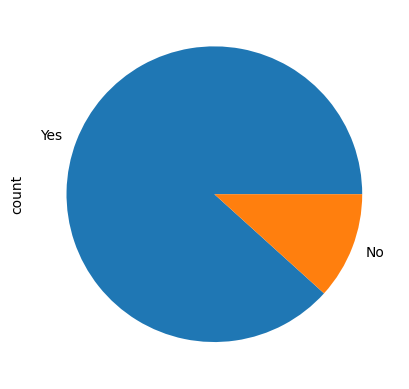

In [615]:
df["Churn"].value_counts().plot(kind="pie")
plt.show()

In [616]:
df.groupby("Churn")['MonthlyCharges'].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [617]:
df.groupby(["Churn","Gender"])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [618]:
df.groupby("ContractType")['MonthlyCharges'].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='ContractType'>

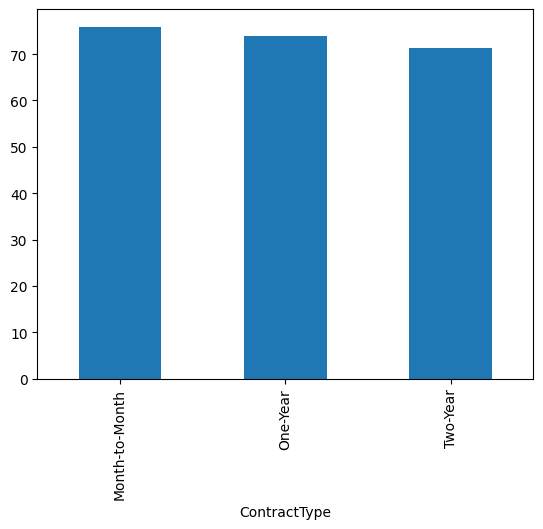

In [619]:
df.groupby("ContractType")['MonthlyCharges'].mean().plot(kind='bar')

<Axes: >

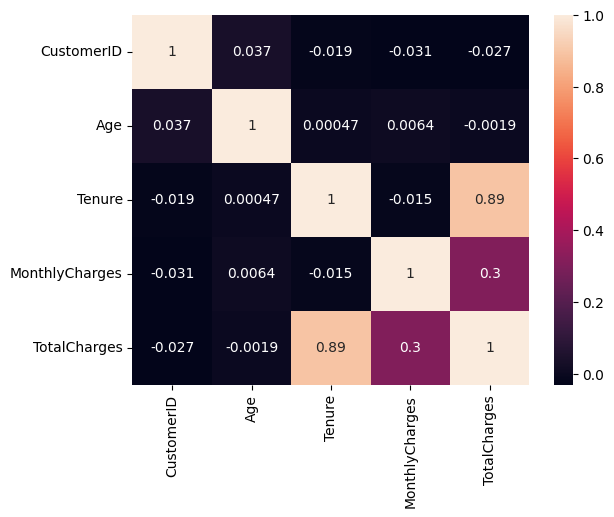

In [620]:
sns.heatmap(cor,annot=True)

In [621]:
df.sample(5)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
818,819,45,Female,4,84.08,Month-to-Month,DSL,336.32,Yes,Yes
718,719,41,Female,19,87.74,Month-to-Month,Fiber Optic,1667.06,Yes,Yes
238,239,38,Male,26,50.93,One-Year,DSL,1324.18,Yes,No
177,178,59,Male,25,92.97,Month-to-Month,Fiber Optic,2324.25,No,Yes
731,732,35,Female,20,44.07,Month-to-Month,DSL,881.40,No,Yes


In [622]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder 

In [623]:


ohe = OneHotEncoder()

encoded = pd.get_dummies(columns=["Gender","TechSupport"],data=df)
encoded




,CustomerID,Age,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,Churn,Gender_Female,Gender_Male,TechSupport_No,TechSupport_Yes
0,1,49,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,False,True,False,True
1,2,43,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,False,True,False,True
2,3,51,2,63.79,Month-to-Month,Fiber Optic,127.58,Yes,True,False,True,False
3,4,60,8,102.34,One-Year,DSL,818.72,Yes,True,False,False,True
4,5,42,32,69.01,Month-to-Month,Fiber Optic,2208.32,Yes,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,42,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,False,True,False,True
996,997,62,9,80.93,Month-to-Month,Fiber Optic,728.37,Yes,False,True,True,False
997,998,51,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,True,False,False,True
998,999,39,68,65.67,One-Year,Fiber Optic,4465.56,Yes,False,True,True,False


In [624]:


le = LabelEncoder()

df["InternetService"] = le.fit_transform(df["InternetService"])

df["Churn"] = le.fit_transform(df["Churn"])

df["Gender"]=le.fit_transform(df["Gender"])

df["ContractType"] = le.fit_transform(df["ContractType"])
df["TechSupport"] = le.fit_transform(df["TechSupport"])
df.sample(5)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
303,304,51,0,2,89.55,0,1,179.10,0,1
322,323,36,0,36,101.63,0,1,3658.68,1,1
589,590,36,1,56,114.09,2,1,6389.04,0,1
438,439,27,1,57,52.20,0,1,2975.40,1,1
442,443,24,1,65,97.85,0,0,6360.25,1,1


In [625]:
df.drop("CustomerID",axis=1,inplace=True)
df


,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,1,4,88.35,0,1,353.40,1,1
1,43,1,0,36.67,0,1,0.00,1,1
2,51,0,2,63.79,0,1,127.58,0,1
3,60,0,8,102.34,1,0,818.72,1,1
4,42,1,32,69.01,0,1,2208.32,0,1
...,...,...,...,...,...,...,...,...,...
995,42,1,41,37.14,0,1,1522.74,1,1
996,62,1,9,80.93,0,1,728.37,0,1
997,51,0,15,111.72,0,1,1675.80,1,1
998,39,1,68,65.67,1,1,4465.56,0,1


In [626]:
X=df.drop(["Churn","InternetService","TechSupport","MonthlyCharges"],axis=1)
y=df["Churn"]

In [627]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [628]:
scal=StandardScaler()
X_train=scal.fit_transform(X_train)
X_test=scal.transform(X_test)

joblib.dump(scal,"scal.pkl")

['scal.pkl']

In [629]:
X_train.shape

(800, 5)

In [630]:
X_train

array([[-0.27936177,  1.06725697,  2.28080878,  1.66760554,  3.06296422],
       [ 0.02664838, -0.93698147,  0.11295321,  0.39340837,  0.50771507],
       [-0.38136516,  1.06725697,  0.69457299,  0.39340837,  0.12087641],
       ...,
       [ 0.23065515,  1.06725697,  1.91068709, -0.88078879,  1.92842064],
       [ 0.02664838, -0.93698147, -0.36291753, -0.88078879,  0.01436398],
       [-0.38136516, -0.93698147,  0.06007868, -0.88078879, -0.21995811]],
      shape=(800, 5))

In [631]:
X_test.shape

(200, 5)

In [632]:
y_train.shape

(800,)

In [633]:
y_test.shape

(200,)

In [634]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy Score on model is {}".format(accuracy_score(y_test,predictions)))

In [635]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr.fit(X_train,y_train)

X

,Age,Gender,Tenure,ContractType,TotalCharges
0,49,1,4,0,353.40
1,43,1,0,0,0.00
2,51,0,2,0,127.58
3,60,0,8,1,818.72
4,42,1,32,0,2208.32
...,...,...,...,...,...
995,42,1,41,0,1522.74
996,62,1,9,0,728.37
997,51,0,15,0,1675.80
998,39,1,68,1,4465.56


In [636]:
y_pred=lr.predict(X_test)
modelperformance(y_pred)

Accuracy Score on model is 0.895


In [637]:
from sklearn.neighbors import KNeighborsClassifier

param_grid={

    "n_neighbors":[3,5,8,10],
    "weights":["Uniform","distance"]
}



In [638]:
knn=KNeighborsClassifier()

In [639]:
grid_kn=GridSearchCV(knn,param_grid,cv=5)

In [640]:
grid_kn.fit(X_train,y_train)
import warnings

warnings.filterwarnings('ignore')
print(grid_kn.best_params_)
print(grid_kn.best_score_)

{'n_neighbors': 10, 'weights': 'distance'}
0.88125


In [641]:
y_pre=grid_kn.predict(X_test)

In [642]:
modelperformance(y_pre)

Accuracy Score on model is 0.89


In [643]:
bestmodel=grid_kn.best_estimator_

In [644]:
import joblib
joblib.dump(bestmodel,"model.pkl")

['model.pkl']

In [645]:
X.columns

Index(['Age', 'Gender', 'Tenure', 'ContractType', 'TotalCharges'], dtype='object')